# Supervised vs Unsupervised Learning

In this notebook we take **one dataset** and use it in two different ways:

1. **Supervised learning**: we give the model the answers (the species of each flower) and it learns to predict them.
2. **Unsupervised learning**: we hide the answers and ask the model to find groups on its own.

At the end we put the two side by side to see what each one can and cannot do.

Run each cell in order with Shift + Enter.

## 1. Setting up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]
MARKERS = ["o", "s", "^"]

## 2. The data

We use the iris dataset: 150 flowers from three species (setosa, versicolor and virginica). To keep things simple
we only use two measurements, the petal length and petal width, both in centimetres. Using two features means we
can draw everything on a flat chart.

In [2]:
iris = load_iris(as_frame=True)
df = iris.frame
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

X = df[["petal length (cm)", "petal width (cm)"]]   # the features
y = df["species"]                                   # the label (the answer)

df[["petal length (cm)", "petal width (cm)", "species"]].head()

,petal length (cm),petal width (cm),species
0,1.4,0.2,setosa
1,1.4,0.2,setosa
2,1.3,0.2,setosa
3,1.5,0.2,setosa
4,1.4,0.2,setosa


### What each type of learning gets to see

The left chart shows the data as an **unsupervised** model sees it: just points, with no idea which species
each flower is. The right chart shows it as a **supervised** model sees it: every point comes with its answer.

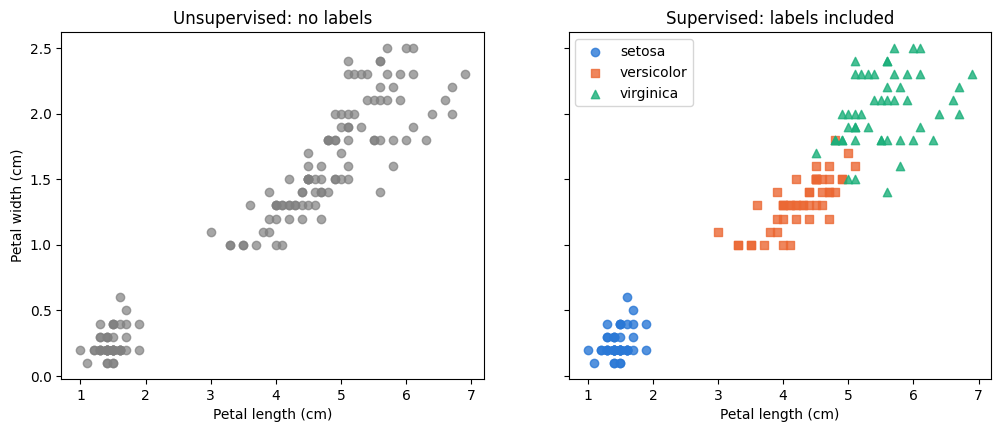

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].scatter(X.iloc[:, 0], X.iloc[:, 1], color="grey", alpha=0.7)
axes[0].set_title("Unsupervised: no labels")

for i, name in enumerate(iris.target_names):
    rows = y == name
    axes[1].scatter(X.loc[rows].iloc[:, 0], X.loc[rows].iloc[:, 1],
                    color=COLOURS[i], marker=MARKERS[i], label=name, alpha=0.8)
axes[1].set_title("Supervised: labels included")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Petal length (cm)")
axes[0].set_ylabel("Petal width (cm)")
plt.show()

---
## 3. Supervised learning: K-nearest neighbours

Here we **do** use the labels. We split the flowers into a training set and a test set, train a
K-nearest neighbours classifier on the training set, and check its predictions on the test set.

Notice that `fit` is given **both** `X_train` and `y_train`: the features and the answers.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)          # features AND labels

accuracy = knn.score(X_test, y_test)
print(f"Test accuracy: {accuracy:.1%} on {len(X_test)} flowers")

Test accuracy: 94.7% on 38 flowers


Because the model learned from labelled examples, we can measure exactly how often it is right. It also
predicts a **species name** for a new flower:

In [5]:
new_flower = pd.DataFrame([[4.8, 1.6]], columns=X.columns)
print("Supervised model says:", knn.predict(new_flower)[0])

Supervised model says: versicolor


---
## 4. Unsupervised learning: K-means clustering

Now we **ignore** the labels completely. We ask K-means to split the flowers into 3 groups based only on
their petal measurements.

Notice that `fit` is given **only** `X`. There is no `y` anywhere in this section.

The two features are both measured in centimetres, so we do not need to scale them here.

In [6]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=0)
kmeans.fit(X)                      # features only, no labels

clusters = kmeans.labels_
print("Flowers in each cluster:", pd.Series(clusters).value_counts().sort_index().to_dict())

Flowers in each cluster: {0: 52, 1: 50, 2: 48}


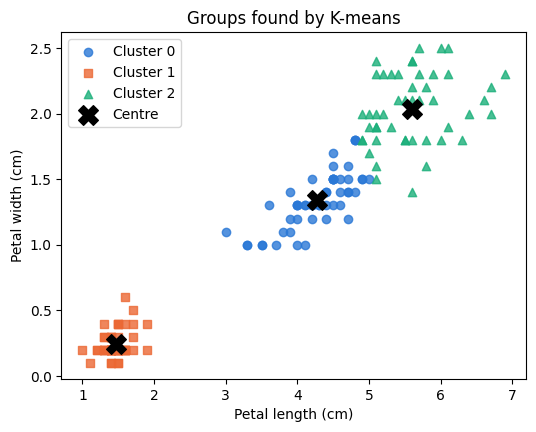

In [7]:
plt.figure(figsize=(6, 4.5))
for c in range(3):
    rows = clusters == c
    plt.scatter(X.loc[rows].iloc[:, 0], X.loc[rows].iloc[:, 1],
                color=COLOURS[c], marker=MARKERS[c], label=f"Cluster {c}", alpha=0.8)
centres = kmeans.cluster_centers_
plt.scatter(centres[:, 0], centres[:, 1], color="black", marker="X", s=200, label="Centre")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Groups found by K-means")
plt.legend()
plt.show()

K-means can also place a new flower into a group, but look at what it returns:

In [8]:
print("Unsupervised model says: cluster", kmeans.predict(new_flower)[0])

Unsupervised model says: cluster 0


The clustering model gives a **number**, not a species name. It found groups, but it has no idea what the
groups are called, because it was never told. A person would have to look at the groups and decide what
they mean.

---
## 5. Comparing the two

Because this dataset does have labels, we can check how well the clusters line up with the real species.
(In a real unsupervised problem we could not do this, because there would be no labels to check against.)

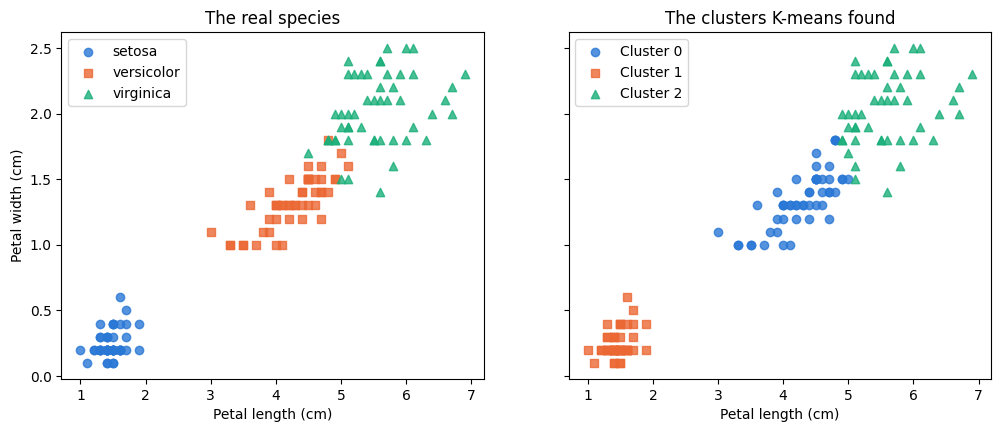

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for i, name in enumerate(iris.target_names):
    rows = y == name
    axes[0].scatter(X.loc[rows].iloc[:, 0], X.loc[rows].iloc[:, 1],
                    color=COLOURS[i], marker=MARKERS[i], label=name, alpha=0.8)
axes[0].set_title("The real species")
axes[0].legend()

for c in range(3):
    rows = clusters == c
    axes[1].scatter(X.loc[rows].iloc[:, 0], X.loc[rows].iloc[:, 1],
                    color=COLOURS[c], marker=MARKERS[c], label=f"Cluster {c}", alpha=0.8)
axes[1].set_title("The clusters K-means found")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Petal length (cm)")
axes[0].set_ylabel("Petal width (cm)")
plt.show()

A table makes the comparison clearer. Each row is a real species and each column is a cluster.

In [10]:
pd.crosstab(y, clusters, rownames=["Real species"], colnames=["Cluster"])

Cluster,0,1,2
Real species,,,
setosa,0,50,0
versicolor,48,0,2
virginica,4,0,46


Reading the table:

- All 50 **setosa** flowers ended up in the same cluster, on their own. Setosa has much smaller petals, so it is easy to separate.
- **Versicolor** and **virginica** overlap a little, so a few flowers were grouped with the other species.
- The cluster numbers (0, 1, 2) do not match the species order. The numbers are just names K-means made up, which is why the colours in the two charts above do not line up.

So K-means found groups that are very close to the real species, without ever being told what the species were.

---
## 6. Summary

| | Supervised (K-nearest neighbours) | Unsupervised (K-means) |
|---|---|---|
| Needs labels? | Yes | No |
| What `fit` is given | `X` and `y` | `X` only |
| What it gives back | A species name | A cluster number |
| How we check it | Accuracy on a test set | No direct check: we look at the groups and decide if they make sense |
| Typical question | "Which species is this flower?" | "Are there natural groups in this data?" |

**Supervised learning** is the right choice when you have examples with the correct answers and want to
predict that answer for new data.

**Unsupervised learning** is useful when you have no labels, and want to find structure or groups that you
did not know about in advance.

## 7. Things to try

1. In Section 4, change `n_clusters` to 2 and then to 4. What happens to the groups? Which value looks most natural?
2. In Section 3, change `n_neighbors` to 1 and then to 25. Does the test accuracy change?
3. Change `X` in Section 2 to use all four measurements (`iris.data`). Both models still work, but you can no longer draw the data on one chart. Does the crosstab in Section 5 change?